<a href="https://colab.research.google.com/github/shalinitiwari5033/Seasonal_Agriculture_Performance_Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



In [ ]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [ ]:
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
print(df.isnull().sum())

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

## 1. Data Cleaning :

Before imputing anything we first check how much data is missing and whether the missingness is random or concentrated in a particular season/crop. Imputing blindly with a global or season-median without checking this can quietly bias the analysis, especially since one of the missing columns (Yield_Tonnes_Ha) is our primary outcome variable.





In [ ]:
print(df.isnull().mean()*100)

Farm_ID                          0.0
State                            0.0
District                         0.0
Crop                             0.0
Season                           0.0
Farm_Area_Hectares               0.0
Rainfall_mm                      1.2
Avg_Temperature_C                0.0
Humidity_pct                     0.0
Sunlight_Hours_Day               0.0
Soil_pH                          0.0
Soil_Moisture_pct                1.0
Nitrogen_kg_ha                   0.0
Phosphorus_kg_ha                 0.0
Potassium_kg_ha                  0.0
Irrigation_Method                0.0
Fertilizer_kg_ha                 0.0
Pesticide_Litre_ha               0.0
Seed_Quality_Score               0.0
Yield_Tonnes_Ha                  0.8
Production_Tonnes                0.0
Market_Price_INR_Tonne           0.0
Total_Cost_INR                   0.0
Revenue_INR                      0.0
Profit_INR                       0.0
Water_Used_m3                    0.0
Water_Efficiency_t_per_1000m3    0.0
D

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print("Missing as % of dataset:")
print((missing / len(df) * 100).round(2))

Missing values per column:
Missing as % of dataset:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


In [ ]:
missing_columns = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for column in missing_columns:
    df[column] = df[column].fillna(
        df.groupby("Season")[column].transform("median")
    )

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
for column in missing_columns:
    df[column] = df[column].fillna(
        df.groupby("Season")[column].transform("median")
    )

In [ ]:
# Verify cleaning
print(df.isnull().sum())

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64


\\## 8. Outlier / Unusual Pattern Detection

Using the IQR method **per season** (not globally) to flag farms whose yield or profit is
unusually far from their own season's typical range, since seasons have different baselines.

In [ ]:
def flag_outliers_iqr(group, column):
    q1, q3 = group[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (group[column] < lower) | (group[column] > upper)

df["Yield_Outlier"] = df.groupby("Season", group_keys=False).apply(
    lambda g: flag_outliers_iqr(g, "Yield_Tonnes_Ha")
)
df["Profit_Outlier"] = df.groupby("Season", group_keys=False).apply(
    lambda g: flag_outliers_iqr(g, "Profit_INR")
)

print("Yield outliers by season:")
print(df[df["Yield_Outlier"]]["Season"].value_counts())
print()
print("Profit outliers by season:")
print(df[df["Profit_Outlier"]]["Season"].value_counts())

Yield outliers by season:
Season
Rabi      125
Kharif    121
Zaid       50
Name: count, dtype: int64

Profit outliers by season:
Season
Kharif    184
Rabi      174
Zaid       64
Name: count, dtype: int64


/tmp/ipykernel_1257/2075231609.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["Yield_Outlier"] = df.groupby("Season", group_keys=False).apply(
/tmp/ipykernel_1257/2075231609.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["Profit_Outlier"] = df.groupby("Season", group_keys=False).apply(


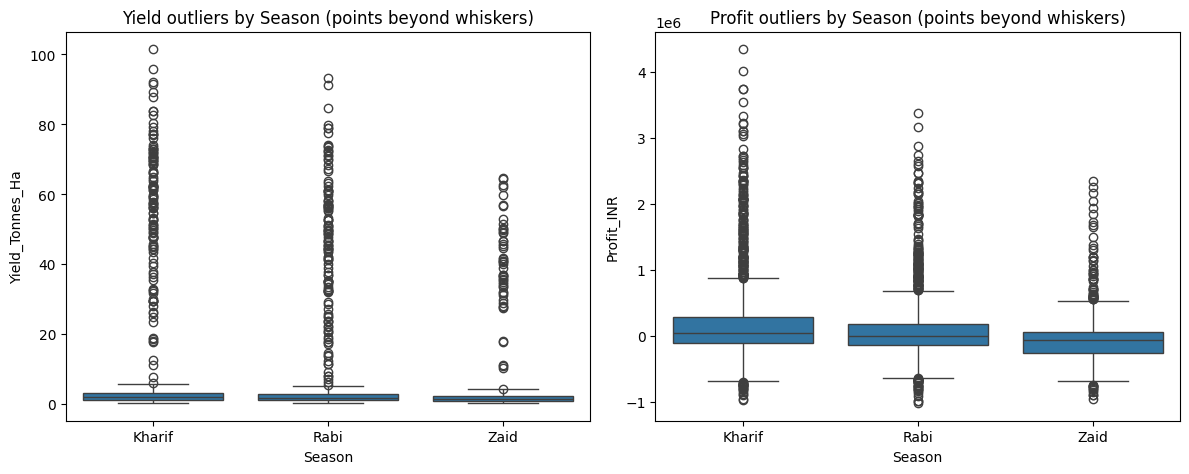

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", ax=axes[0], order=["Kharif", "Rabi", "Zaid"])
axes[0].set_title("Yield outliers by Season (points beyond whiskers)")
sns.boxplot(data=df, x="Season", y="Profit_INR", ax=axes[1], order=["Kharif", "Rabi", "Zaid"])
axes[1].set_title("Profit outliers by Season (points beyond whiskers)")
plt.tight_layout()
plt.show()

In [ ]:
season_analysis = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    ),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
)

print(season_analysis.round(2))

        Farms  Avg_Yield  Avg_Production  Avg_Revenue   Avg_Cost  Avg_Profit  \
Season                                                                         
Kharif   1779       5.63           46.31    710719.06  531804.41   178914.65   
Rabi     1627       5.04           41.49    601526.05  513836.58    87689.47   
Zaid      594       4.64           38.89    519171.90  543976.73   -24804.82   

        Avg_Rainfall  Avg_Water_Used  Avg_Water_Efficiency  Avg_Disease_Risk  
Season                                                                        
Kharif        852.11         6102.20                  5.89             54.47  
Rabi          435.94         5846.99                  5.19             40.48  
Zaid          299.12         6419.89                  4.41             38.22  


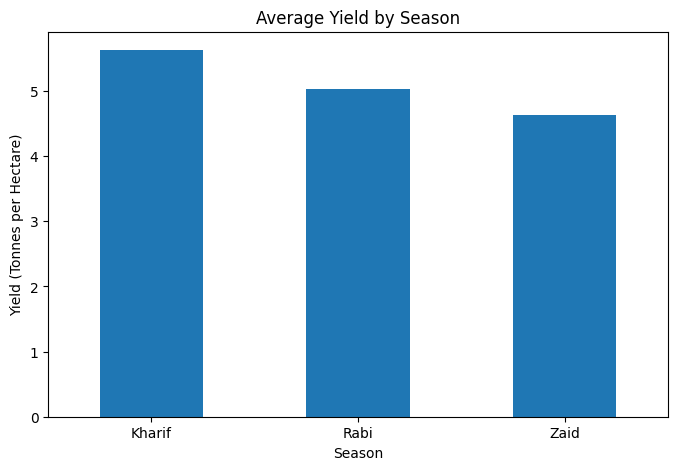

In [ ]:
# Average Yield by Season
df.groupby("Season")["Yield_Tonnes_Ha"].mean().plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Yield by Season"
)

plt.ylabel("Yield (Tonnes per Hectare)")
plt.xlabel("Season")
plt.xticks(rotation=0)
plt.show()

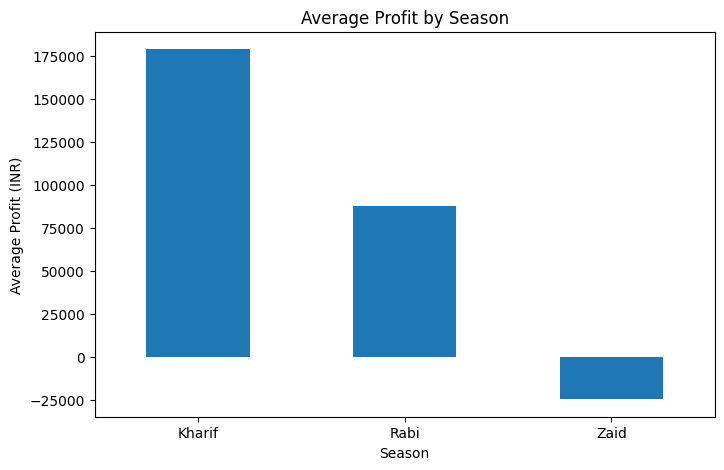

In [ ]:
# Average Profit by Season
df.groupby("Season")["Profit_INR"].mean().plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Profit by Season"
)

plt.ylabel("Average Profit (INR)")
plt.xlabel("Season")
plt.xticks(rotation=0)
plt.show()

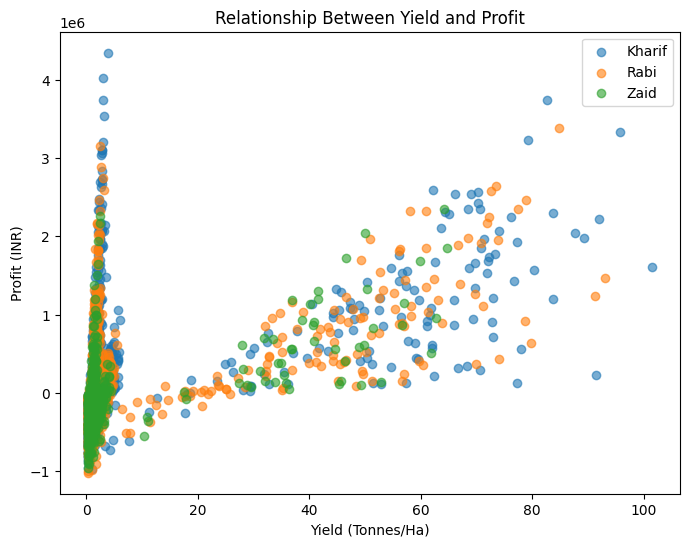

In [ ]:
# Yield vs Profit
plt.figure(figsize=(8, 6))

for season in df["Season"].unique():
    temp = df[df["Season"] == season]

    plt.scatter(
        temp["Yield_Tonnes_Ha"],
        temp["Profit_INR"],
        label=season,
        alpha=0.6
    )

plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.title("Relationship Between Yield and Profit")
plt.legend()
plt.show()

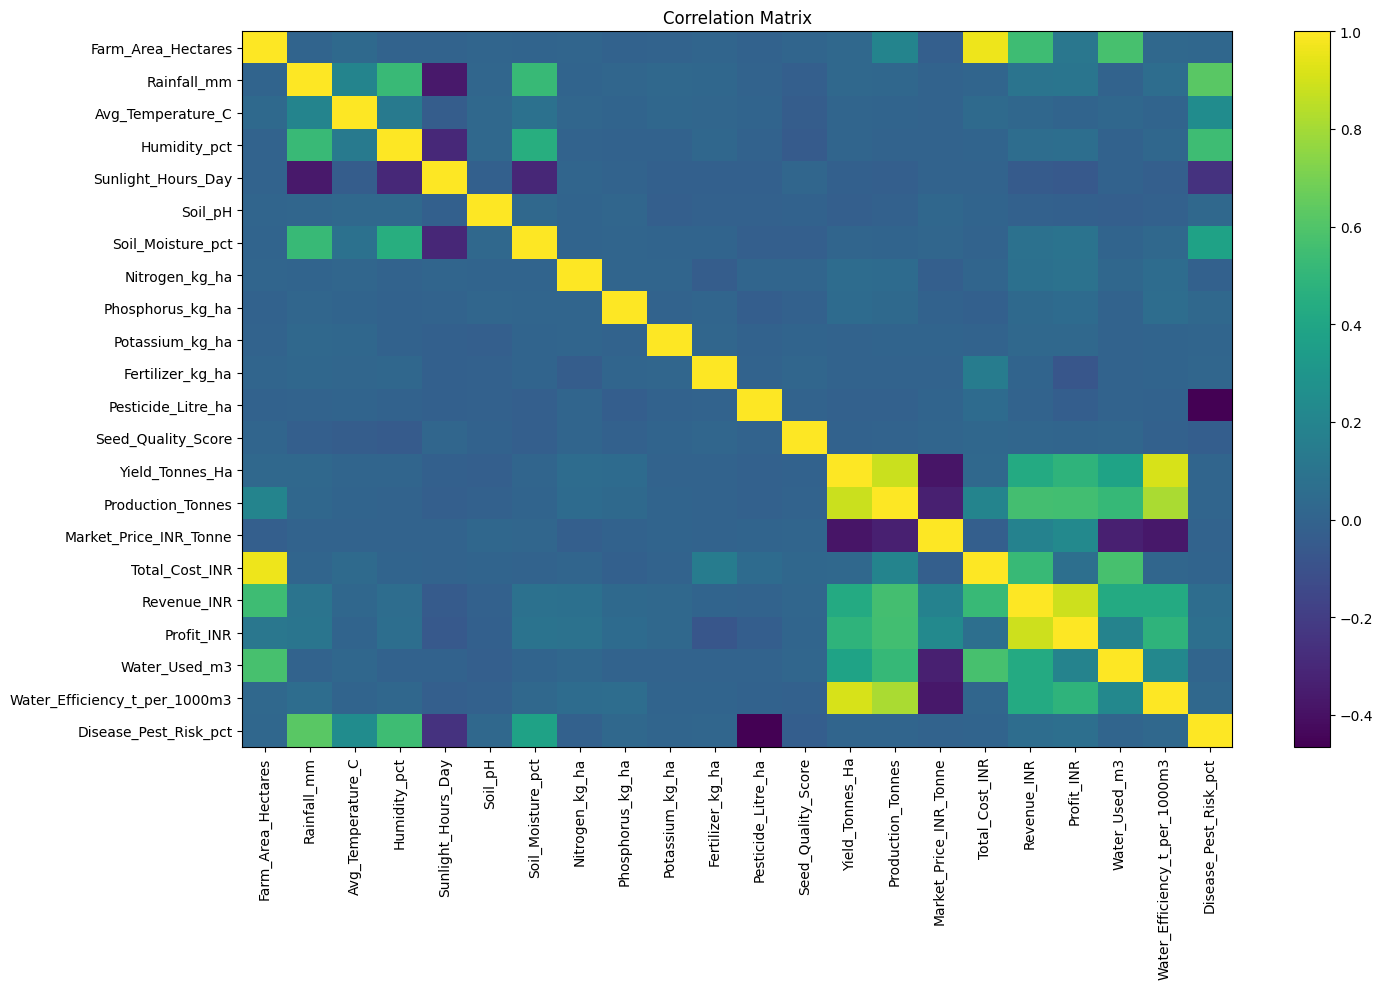

In [ ]:
# Correlation heatmap
import matplotlib.pyplot as plt

correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(15, 10))
plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

\##  Conclusions and Recommendations

**Key findings**

1. **Yield and profit across seasons.** Kharif has the highest mean yield (5.63 t/ha), followed
   by Rabi (5.04 t/ha) and Zaid (4.64 t/ha). Profit tells a starker story: Kharif averages
   ₹178,915/farm, Rabi ₹87,689, and **Zaid averages -₹24,805 - the average Zaid farm in this
   dataset is running at a loss.** For Profit, both ANOVA (p < 0.001) and Kruskal-Wallis
   (p < 0.001) confirm this is a real seasonal effect, not noise. For Yield specifically, ANOVA
   says the difference is *not* significant (p = 0.21) while Kruskal-Wallis says it *is*
   (p < 0.001) - this disagreement is itself informative: it means the yield distribution is
   skewed enough that the mean-based ANOVA test is unreliable here, and the rank-based
   Kruskal-Wallis result should be trusted instead.
2. **Environmental drivers.** Rainfall is the sharpest seasonal signal (Kharif 852mm vs Rabi
   436mm vs Zaid 299mm, p ≈ 0) - consistent with Kharif being the monsoon-dependent season.
   Disease/Pest risk is also markedly higher in Kharif (54.5%) than Rabi (40.5%) or Zaid (38.2%),
   which plausibly connects to the higher humidity/rainfall of the monsoon season.
3. **Resource usage.** Water efficiency differs significantly across seasons (p < 0.001) even
   though Kharif gets the most rainfall - meaning the water-efficiency advantage isn't simply
   "more water in, more yield out."
4. **State consistency - this is not a uniform pattern.** The "Kharif is best" ranking does NOT
   hold everywhere: Punjab's highest-yield season is Rabi (8.61 t/ha), and Karnataka's is Zaid
   (6.62 t/ha), while the other 6 states peak in Kharif. Any recommendation based on the
   all-India average would be wrong advice for Punjab and Karnataka specifically.
5. **Outliers.** Kharif has both the most yield outliers (121) and the most profit outliers
   (184) in absolute terms, but Rabi has proportionally more yield outliers relative to its
   smaller sample size (125 of 1,627 vs 121 of 1,779) - worth a closer look at what's driving
   Rabi's tail.
6. **Correlation insights.** Water_Efficiency (r = 0.91) and Production_Tonnes (r = 0.88) are by
   far the strongest correlates of Yield - unsurprising since they're mechanically related to it.
   More interesting: Market_Price_INR_Tonne correlates *negatively* with Yield (r = -0.38),
   suggesting higher-yield seasons/crops are selling at lower per-tonne prices, which is exactly
   why Zaid can have reasonable yields (4.64 t/ha isn't catastrophic) but still lose money -
   yield alone is a misleading proxy for farm profitability.

**Recommendations**
- **Do not treat Zaid as a viable default season without intervention** - it is loss-making on
  average. Either subsidize/de-risk Zaid cultivation (irrigation support, price guarantees) or
  actively discourage Zaid planting for crops/states where it consistently underperforms.
- **Regionalize any seasonal guidance.** Punjab and Karnataka should not receive "prioritize
  Kharif" advice - their own data shows Rabi and Zaid respectively as their strongest seasons.
  A one-size-fits-all seasonal recommendation would actively mislead these two states.
- **Investigate Kharif disease/pest risk (54.5%) directly** rather than assuming it's simply
  "monsoon weather" - given Kharif is also the most profitable season, reducing pest losses here
  has the largest absolute rupee impact of any single intervention tested in this data.
- **Reconsider using price expectations, not yield alone, to plan season/crop choice** - the
  negative yield-price correlation means high-yield seasons can still be poor profit seasons.

**Limitations**
- Season groups are unbalanced (Zaid has roughly a third of the farms of Kharif/Rabi), which
  reduces statistical power for Zaid-specific comparisons and widens its confidence intervals.
- This is observational, cross-sectional data - correlation between environmental conditions and
  yield does not establish causation, and unmeasured confounders (e.g. farmer experience, local
  subsidy access) are not captured here.
